# Modelling the COLIBRE cores

In [1]:
import numpy as np
import dill

from scipy.optimize import curve_fit

from astropy import units as u
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo

In [2]:
from matplotlib import pyplot as plt

# Use TeX
from matplotlib import rc
rc('font', size=18)
rc('text', usetex=True)
rc('font', family='serif')

# 1. Data

<b>Important note:</b> In all what follows, kappabar refers to the disk-averaged convergence, that is
$$
\bar{\kappa}(\theta)
=
\frac{1}{\pi\theta^2} \int_{|\boldsymbol{\theta}'|<\theta} \mathrm{d}^2\boldsymbol{\theta}' \; \kappa(\boldsymbol{\theta}') .
$$

Hence, by definition, this quantity is unity at the Einstein radius.

In [3]:
# Load the file

with open("kw_kappa_r.dll","rb") as f:
   data = dill.load(f)

rs = data['rs']
kappabars = data['kappas']
REs = data['REs']
arcXkpcs = data['arcXkpcs'][0]
thetaEs = [RE * arcXkpcs for RE in REs]

In [4]:
# Keep only the galaxies with large Einstein radii

thetaEmin = 0.3 * u.arcsec
lenses = [g for g in range(len(rs)) if thetaEs[g] > thetaEmin]

xs_lenses = [rs[l]/REs[l] for l in lenses]
kappabars_lenses = [kappabars[l] for l in lenses]

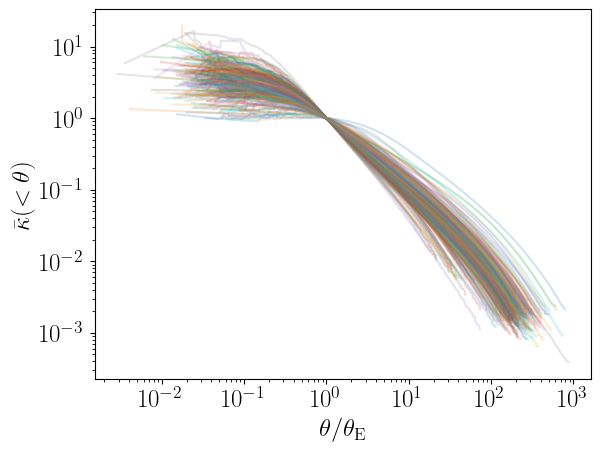

In [5]:
for l in range(len(xs_lenses)):
    plt.loglog(xs_lenses[l], kappabars_lenses[l], alpha=0.2)
    
plt.xlabel(r'$\theta/\theta_{\rm E}$')
plt.ylabel(r'$\bar{\kappa}(<\theta)$')
plt.show();

# 2. Direct modelling

I use the following model
$$
\bar{\kappa}(x) = \left[ \frac{1 + (1/x_{\rm c})^s}{1 + (x/x_{\rm c})^s} \right]^{\frac{\gamma-1}{s}}
$$
with $x\equiv \theta/\theta_{\rm E}$ and $x_{\rm c}\equiv \theta_{\rm c}/\theta_{\rm E}$ is the normalised core size, $\gamma$ the outer power-law index ($\gamma=2$ for isothermal), and $s$ quantifies the sharpness of the core-to-power-law transition.

The model has the following properties:
- $\bar{\kappa}(1)=1$ by definition of the Einstein radius;
- $\bar{\kappa}(x\gg 1)\approx (x/x_{\rm c})^{1-\gamma}$, this is the outer power law.
- $\bar{\kappa}(x\ll x_{\rm c})\approx\left[ 1 + (1/x_{\rm c})^s\right]^{\frac{\gamma-1}{s}}\equiv \kappa_{\rm c}$, which is also the central convergence. For a very small core size, $x_{\rm c}\ll 1$, this reads $\kappa_{\rm c}\approx x_{\rm c}^{1-\gamma}$.

In [6]:
def kappabar_model(x, x_core, sharpness, outer_slope):
    """
    Empirical model for kappabar. The normalisation N ensures that kappabar(x=1) = 1,
    that is at the Einstein radius.
    x_core is the core size
    outer_slope is the outer power-law index
    sharpness is the sharpness of the core-to-power-law transition
    """
    
    N = (1 + (1/x_core)**sharpness)**((outer_slope-1)/sharpness)
    kappabar = N / (1 + (x/x_core)**sharpness)**((outer_slope-1)/sharpness)
    
    return kappabar

Fitting the data

In [7]:
x_max = 10 # maximum ratio of r/rE that we model
x_core, sharpness, outer_slope = [], [], [] # list of best-fit parameters


for lens in range(len(lenses)):
    
    x_ = xs_lenses[lens]
    x = x_[x_<x_max] # cut the profile beyond r/rE > x_max
    kappabar = kappabars_lenses[lens][:len(x)]

    # make fit
    popt, pcov = curve_fit(kappabar_model, x, kappabar, bounds=([1e-2, 0.5, 0.5], [10, 20, 4]))
    
    x_core.append(popt[0])
    sharpness.append(popt[1])
    outer_slope.append(popt[2])

    
x_core      = np.array(x_core)
sharpness   = np.array(sharpness)
outer_slope = np.array(outer_slope)

Illustration

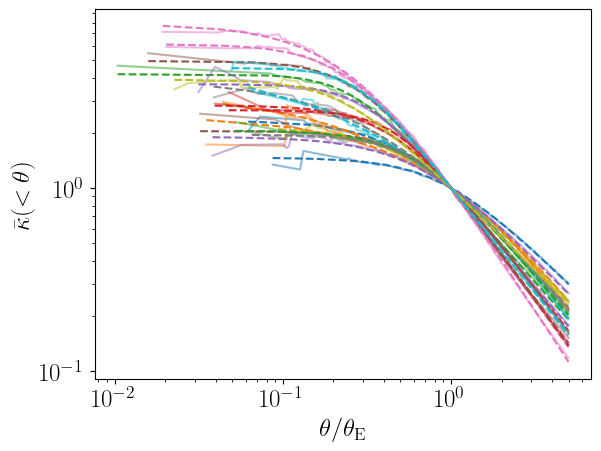

In [8]:
x_max = 5
rng = np.random.default_rng()
sample = rng.integers(len(lenses)-1, size=20)
xmax = 10

colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, lens in enumerate(sample):
    
    x_ = xs_lenses[lens]
    x = x_[x_<x_max] # cut the profile beyond r/rE > x_max
    kappabar = kappabars_lenses[lens][:len(x)]
    
    colour = colours[i % len(colours)]
    
    plt.loglog(x, kappabar, '-', c=colour, alpha = 0.5)
    plt.loglog(x, kappabar_model(x, x_core[lens], sharpness[lens], outer_slope[lens]), '--', c=colour)

plt.xlabel(r"$\theta/\theta_{\rm E}$")
plt.ylabel(r"$\bar{\kappa}(<\theta)$")
plt.show();

Distribution of the best-fit parameters

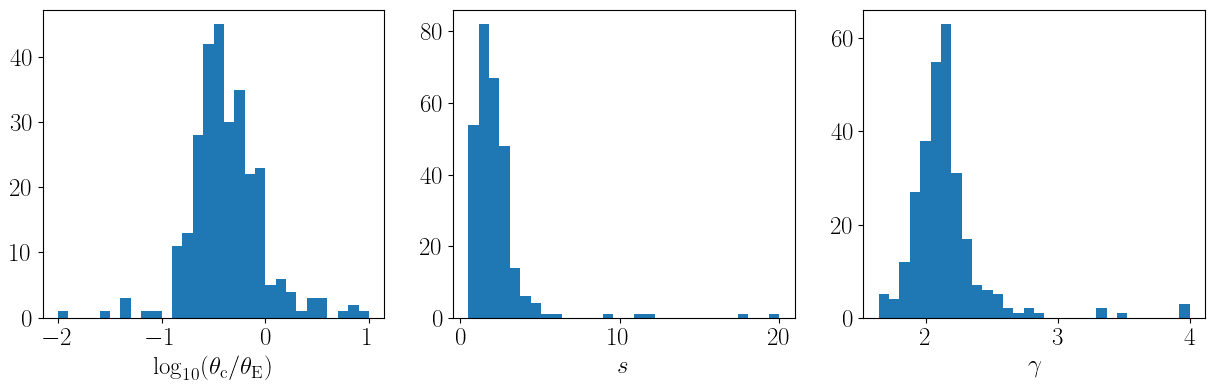

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax=axes[0]
ax.hist(np.log10(x_core), bins=30)
ax.set_xlabel(r'$\log_{10}(\theta_{\rm c}/\theta_{\rm E}$)')

ax=axes[1]
ax.hist(sharpness, bins=30)
ax.set_xlabel(r'$s$')

ax=axes[2]
ax.hist(outer_slope, bins=30)
ax.set_xlabel(r'$\gamma$')

plt.show()

The parameters are not strongly correlated here

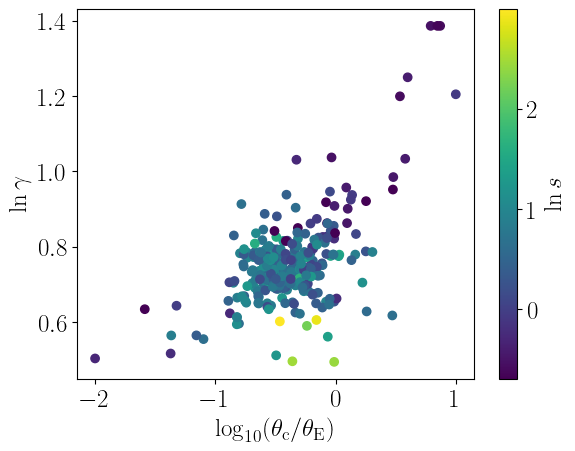

In [10]:
fig, ax = plt.subplots()

scatter = ax.scatter(np.log10(x_core), np.log(outer_slope), c=np.log(sharpness))
fig.colorbar(scatter, ax=ax, label=r'$\ln s$')

ax.set_xlabel(r'$\log_{10}(\theta_{\rm c}/\theta_{\rm E}$)')
ax.set_ylabel(r'$\ln\gamma$')

plt.show()

# 3. Model deriving from a simple potential

If we instead start from a cored model at the level of the potential,
$$
\psi(x) = \psi_0 \left[1 + (x/x_{\rm c})^s\right]^{\frac{3-\gamma}{s}} ,
$$
then the average convergence is found to read
$$
\bar{\kappa}(x)
=
x^{s-2} \left[\frac{1+(1/x_{\rm c})^s}{1+(x/x_{\rm c})^s}\right]^{1+\frac{\gamma-3}{s}} ,
$$
whose properties are similar to the previous model.

In [11]:
def kappabar_model_2(x, x_core, sharpness, outer_slope):
    """
    Empirical model for kappa. The normalisation N ensures that kappa(x=1) = 1,
    that is at the Einstein radius, as seems to be the case on the above plot.
    I tried to let it free and the results are in excellent agreement with the expression here.
    """
    
    N = (1 + (1/x_core)**sharpness)**((3-outer_slope)/sharpness-1)
    kappabar = x**(sharpness-2) * (1 + (x/x_core)**sharpness)**((3-outer_slope)/sharpness-1) / N
    
    return kappabar

x_core, sharpness, outer_slope = [0.64095604 2.3062636  1.79142127]


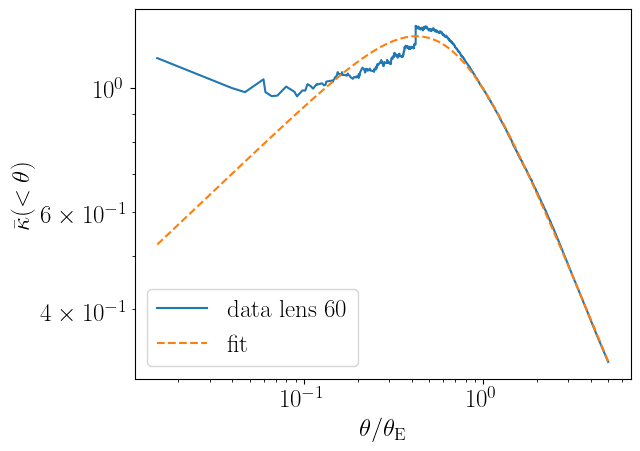

In [12]:
x_max = 5
rng = np.random.default_rng()
lens = rng.integers(len(lenses)-1)

x_ = xs_lenses[lens]
x = x_[x_<x_max] # cut the profile beyond r/rE > x_max
kappabar = kappabars_lenses[lens][:len(x)]

# make fit
popt, pcov = curve_fit(kappabar_model_2, x, kappabar, bounds=([1e-2, 1, 0.5], [10, 10, 4]))
print("x_core, sharpness, outer_slope =", popt)

plt.loglog(x, kappabar, '-', label="data lens {}".format(lens))
plt.loglog(x, kappabar_model_2(x, *popt), '--', label=r"fit")

plt.xlabel(r"$\theta/\theta_{\rm E}$")
plt.ylabel(r"$\bar{\kappa}(<\theta)$")
plt.legend()
plt.show();

I tried with a few lenses and this model performs pretty well too.

In [13]:
x_max = 10 # maximum ratio of r/rE that we model
x_core, sharpness, outer_slope = [], [], [] # list of best-fit parameters


for lens in range(len(lenses)):
    
    x_ = xs_lenses[lens]
    x = x_[x_<x_max] # cut the profile beyond r/rE > x_max
    kappabar = kappabars_lenses[lens][:len(x)]

    # make fit
    popt, pcov = curve_fit(kappabar_model_2, x, kappabar, bounds=([1e-2, 1, 0.5], [10, 20, 4]))
    
    x_core.append(popt[0])
    sharpness.append(popt[1])
    outer_slope.append(popt[2])
    
x_core = np.array(x_core)
sharpness = np.array(sharpness)
outer_slope = np.array(outer_slope)

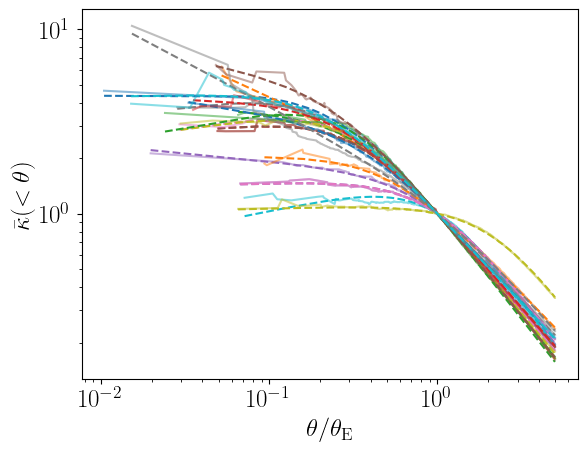

In [14]:
x_max = 5
rng = np.random.default_rng()
sample = rng.integers(len(lenses)-1, size=20)
xmax = 10

colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, lens in enumerate(sample):
    
    x_ = xs_lenses[lens]
    x = x_[x_<x_max] # cut the profile beyond r/rE > x_max
    kappabar = kappabars_lenses[lens][:len(x)]
    
    colour = colours[i % len(colours)]
    
    plt.loglog(x, kappabar, '-', c=colour, alpha = 0.5)
    plt.loglog(x, kappabar_model_2(x, x_core[lens], sharpness[lens], outer_slope[lens]), '--', c=colour)

plt.xlabel(r"$\theta/\theta_{\rm E}$")
plt.ylabel(r"$\bar{\kappa}(<\theta)$")
plt.show();

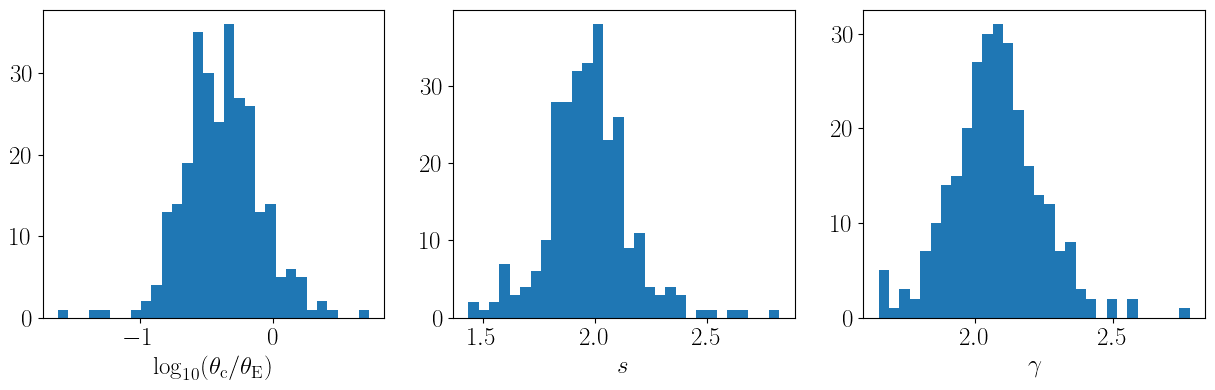

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax=axes[0]
ax.hist(np.log10(x_core), bins=30)
ax.set_xlabel(r'$\log_{10}(\theta_{\rm c}/\theta_{\rm E}$)')

ax=axes[1]
ax.hist(sharpness, bins=30)
ax.set_xlabel(r'$s$')

ax=axes[2]
ax.hist(outer_slope, bins=30)
ax.set_xlabel(r'$\gamma$')

plt.show()

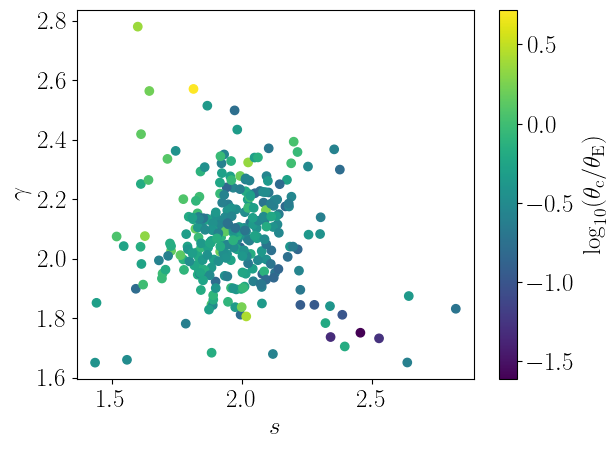

In [16]:
fig, ax = plt.subplots()

scatter = ax.scatter(sharpness, outer_slope, c=np.log10(x_core))
fig.colorbar(scatter, ax=ax, label=r'$\log_{10}(\theta_{\rm c}/\theta_{\rm E}$)')

ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$\gamma$')

plt.show()